## PROCESAMEINTO Y LiMPIEZA  DE FUENTES
-  Autor: Germán Homero Morán Figueroa
- Descripción: Este notebook permite realizar la limpieza y depuración  de la fuente controls.csv, con el objetivo de consolidar bases limpias para la contrucción de la vista minable que sirve de insumo para los modelo de Machine Learning
-  Salida: Dataframe eventos finales, que icluye información de los controles realizados al cultivo del maiz en cada etapa del cultivo

In [2]:
# Librerias y dependencias
# =========================================================================
import pandas as pd
import numpy as np
from unidecode import  unidecode
import plotly.express as px
import re
pd.options.display.max_columns = None

In [3]:
# Funciones Utilizadas para la generación de las nuevas columnas
# =============================================================================================


# Numero de Controles Enfoque Quimico para cada una de las Etapas [Siembra-Emergencia -Floración-Cosecha]
# =======================================================================================================

def funcion1(x):
    if (x.FECHA_CONTROL < x.FECHA_SIEMBRA) and  x.ContTip == "contEnfQui":
        return 1
    else:
        return 0


def funcion2(x):
    if ((x.FECHA_CONTROL < x.FECHA_EMERGENCIA) and (x.FECHA_CONTROL >= x.FECHA_SIEMBRA) and x.ContTip == "contEnfQui"):
        return 1
    else:
        return 0


def funcion3(x):
    if ((x.FECHA_CONTROL < x.FECHA_FLORACION) and (x.FECHA_CONTROL >= x.FECHA_EMERGENCIA) and x.ContTip == "contEnfQui"):
        return 1
    else:
        return 0


def funcion4(x):
    if ((x.FECHA_CONTROL <= x.FECHA_COSECHA) and (x.FECHA_CONTROL >= x.FECHA_FLORACION) and x.ContTip == "contEnfQui"):
        return 1
    else:
        return 0


In [24]:
# Numero de Controles Malezas Mecanizado para cada una de las Etapas [Siembra - Emergencia - Floración -Cosecha]
# ===============================================================================================================

def funcion5(x):
    if (x.FECHA_CONTROL < x.FECHA_SIEMBRA) and  x.ContTip == "contMalMec":
        return 1
    else:
        return 0


def funcion6(x):
    if ((x.FECHA_CONTROL < x.FECHA_EMERGENCIA) and (x.FECHA_CONTROL >= x.FECHA_SIEMBRA) and x.ContTip == "contMalMec"):
        return 1
    else:
        return 0


def funcion7(x):
    if ((x.FECHA_CONTROL < x.FECHA_FLORACION) and (x.FECHA_CONTROL >= x.FECHA_EMERGENCIA) and x.ContTip == "contMalMec"):
        return 1
    else:
        return 0


def funcion8(x):
    if ((x.FECHA_CONTROL <= x.FECHA_COSECHA) and (x.FECHA_CONTROL >= x.FECHA_FLORACION) and x.ContTip == "contMalMec"):
        return 1
    else:
        return 0



In [5]:
# Numero de Control Malezas Quimico para cada una de las Etapas [Siembra - Emergencia - Floración -Cosecha]
# ===================================================================================================================

def funcion9(x):
    if (x.FECHA_CONTROL < x.FECHA_SIEMBRA) and  x.ContTip == "contMalQuí":
        return 1
    else:
        return 0


def funcion10(x):
    if ((x.FECHA_CONTROL < x.FECHA_EMERGENCIA) and (x.FECHA_CONTROL >= x.FECHA_SIEMBRA) and x.ContTip == "contMalQui"):
        return 1
    else:
        return 0


def funcion11(x):
    if ((x.FECHA_CONTROL < x.FECHA_FLORACION) and (x.FECHA_CONTROL >= x.FECHA_EMERGENCIA) and x.ContTip == "contMalQui"):
        return 1
    else:
        return 0


def funcion12(x):
    if ((x.FECHA_CONTROL <= x.FECHA_COSECHA) and (x.FECHA_CONTROL >= x.FECHA_FLORACION) and x.ContTip == "contMalQui"):
        return 1
    else:
        return 0


In [6]:
# Numero de  Control Plagas Quimico para cada una de las Etapas [Siembra - Emergencia - Floración -Cosecha]
# =====================================================================================================================


def funcion13(x):
    if (x.FECHA_CONTROL < x.FECHA_SIEMBRA) and  x.ContTip == "contPlaQuí":
        return 1
    else:
        return 0


def funcion14(x):
    if ((x.FECHA_CONTROL < x.FECHA_EMERGENCIA) and (x.FECHA_CONTROL >= x.FECHA_SIEMBRA) and x.ContTip == "contPlaQui"):
        return 1
    else:
        return 0


def funcion15(x):
    if ((x.FECHA_CONTROL < x.FECHA_FLORACION) and (x.FECHA_CONTROL >= x.FECHA_EMERGENCIA) and x.ContTip == "contPlaQui"):
        return 1
    else:
        return 0


def funcion16(x):
    if ((x.FECHA_CONTROL <= x.FECHA_COSECHA) and (x.FECHA_CONTROL >= x.FECHA_FLORACION) and x.ContTip == "contPlaQui"):
        return 1
    else:
        return 0

In [7]:
# Lectura del Archivo Controls
# ===================================================================
controls = pd.read_csv("../../Data/Bronze/Controls_3.csv")
print("Cantidad de registros Iniciales en el datset: ",controls.shape)
controls.head(2)

Cantidad de registros Iniciales en el datset:  (7590, 6)


,ID_EVENTO,ID_PROD,FECHA_CONTROL,TIPO_OBJETIVO,TIPO_CONTROL,MOLECULA_ACTIVA
0,16,34,5/1/2013,Plagas,Químico,PROFENOFOS 50% + LUFENURON
1,16,34,5/1/2013,Malezas,Químico,Glifosato


In [8]:
# Lectura de archivo procesados  [Eventos Cordoba y Eventos Clima]
# ============================================================================
evento_cordoba = pd.read_csv("../../Data/Silver/eventos_cordoba_2017.csv")
evenParaClima = pd.read_csv("../../Data/Silver/cordoba_clima.csv")
eventosParaFechas = pd.read_csv("../../Data/Silver/cordoba_fechas_stages.csv")

In [9]:
# Se recuperan unicamante los registros pertenecientes al departamento de Cordoba
# ================================================================================
Lista_IDEvento_Unicos_cordoba = list (evento_cordoba.ID_EVENTO.unique())
print("Cantidad de eventos unicos del departamento de cordoba: ", len(Lista_IDEvento_Unicos_cordoba))

Cantidad de eventos unicos del departamento de cordoba:  882


Cantidad de registro de controles filtrados de acuerdo al ID Evento:  3128
Total de registros:  (3128, 6)


<AxesSubplot:>

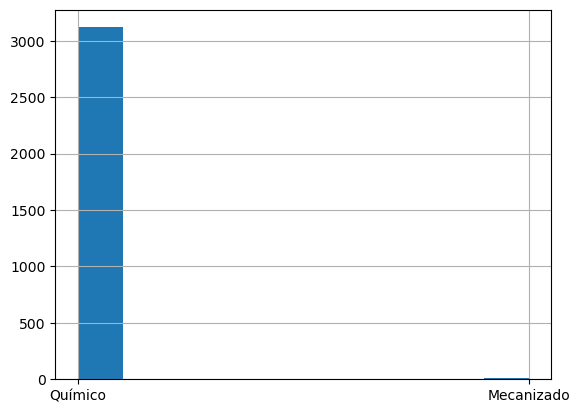

In [10]:
'''
 Se filtra el dataset controls con los IDs  de Eventos unicos pertenecientes a dicho departamento (Cordoba)
'''
controls = controls[controls.ID_EVENTO.isin(Lista_IDEvento_Unicos_cordoba)]
print("Cantidad de registro de controles filtrados de acuerdo al ID Evento: ", len(controls))
# Total de registros del archivo
print("Total de registros: ",controls.shape)
# Diagrama de frecuencias del tipo de control
controls.TIPO_CONTROL.hist()

**Nota** La mayoria de controles aplicados a cada uno de los eventos de cultivo son Quimicos, hay pocos controles mecanizados.

In [11]:
# Resumen del dataset controls
# ====================================================================
controls.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3128 entries, 45 to 7395
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ID_EVENTO        3128 non-null   int64 
 1   ID_PROD          3128 non-null   int64 
 2   FECHA_CONTROL    3128 non-null   object
 3   TIPO_OBJETIVO    3128 non-null   object
 4   TIPO_CONTROL     3128 non-null   object
 5   MOLECULA_ACTIVA  3119 non-null   object
dtypes: int64(2), object(4)
memory usage: 171.1+ KB


In [12]:
# Eliminar los registros duplicados
controls_duplicados = controls.copy()
controls_duplicados.duplicated()
# Si solamente tienen diferente el ID no se eliminan
controls_duplicados= controls_duplicados.drop_duplicates()
# Aqui se elimina 2 duplicados Unicmanete
controls_duplicados.shape

(3126, 6)

In [13]:
# Eliminamos los duplicados  teniendo en cuenta la variable Original
controls = controls.drop_duplicates()
controls.shape

(3126, 6)

In [14]:
# Se eliminan las tildes asociadas a la variable Tipos Control
# =============================================================
controls.TIPO_CONTROL = controls.TIPO_CONTROL.apply(lambda x: x.replace("í","i"))
controls.TIPO_CONTROL


45      Quimico
46      Quimico
47      Quimico
48      Quimico
49      Quimico
         ...   
7391    Quimico
7392    Quimico
7393    Quimico
7394    Quimico
7395    Quimico
Name: TIPO_CONTROL, Length: 3126, dtype: object

In [15]:
controls .head(5)

,ID_EVENTO,ID_PROD,FECHA_CONTROL,TIPO_OBJETIVO,TIPO_CONTROL,MOLECULA_ACTIVA
45,53,13,6/6/2013,Plagas,Quimico,Cipermetrina
46,53,13,6/11/2013,Malezas,Quimico,Glifosato
47,54,14,6/29/2013,Plagas,Quimico,Cipermetrina
48,54,14,6/25/2013,Malezas,Quimico,Glifosato
49,56,15,6/5/2013,Malezas,Quimico,Glifosato


In [16]:
# Ref: https://towardsdatascience.com/apply-and-lambda-usage-in-pandas-b13a1ea037f7


''' Se crea una nueva columna denominada ContTip, alamacena tipos de datos String
    Esta columna la siguiente estructura:
    - Cont + "3 primeras letras del valor de la columnas TIPO_OBJETIVO + 3 primeras letras del valor de la columna TIPO_CONTROL"
'''


# Funcion para concatenar Strings y generar la nueva columnas ConTip

def funcionConcatenarTexto(cadena1,cadena2):
    nuevacadena = "cont"+cadena1[0:3]+cadena2[0:3]
    return nuevacadena


controls["ContTip"] = controls.apply(lambda x: funcionConcatenarTexto(x.TIPO_OBJETIVO,x.TIPO_CONTROL),axis=1)


In [17]:
# Verificacion de la nueva transformación
controls.ContTip

45      contPlaQui
46      contMalQui
47      contPlaQui
48      contMalQui
49      contMalQui
           ...    
7391    contMalQui
7392    contPlaQui
7393    contMalQui
7394    contPlaQui
7395    contMalQui
Name: ContTip, Length: 3126, dtype: object

In [18]:
''' 
Se genera una tabla donde por cada valor de la columna id_evento se observa el
numero de repeticiones en los valores encontrados en la columna ContTip.

Dicho de otro modo: cantidad de controles realizados por cada ( objetivo y tipo) para cada cultivo  '''

cont = pd.crosstab(index=controls.ID_EVENTO, columns=controls.ContTip)
cont

ContTip,contEnfQui,contMalMec,contMalQui,contPlaQui
ID_EVENTO,,,,
53,0,0,1,1
54,0,0,1,1
56,0,0,1,0
57,0,0,2,0
273,0,0,1,1
...,...,...,...,...
4671,0,0,1,2
4672,0,0,1,2
4673,0,0,1,2


In [19]:
# Resumen del nuevo datset
# =========================
cont.describe()

ContTip,contEnfQui,contMalMec,contMalQui,contPlaQui
count,836.000000,836.000000,836.000000,836.000000
mean,0.167464,0.010766,1.637560,1.923445
std,0.435759,0.114270,0.909814,1.400214
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,1.000000
50%,0.000000,0.000000,2.000000,2.000000
75%,0.000000,0.000000,2.000000,2.000000
max,3.000000,2.000000,5.000000,12.000000


In [20]:
# Tranformación de FECHA CONTROL A formato date_time
controls.FECHA_CONTROL = pd.to_datetime(controls.FECHA_CONTROL,infer_datetime_format=True)


C:\Users\germanm\AppData\Local\Temp\ipykernel_3940\324416353.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  controls.FECHA_CONTROL = pd.to_datetime(controls.FECHA_CONTROL,infer_datetime_format=True)


In [21]:
'''
Se adiciona al dataframe controls las columnas que contienen información de
fechas de siembra, emergencia, floracion y cosecha de los cultivos'''

controlesEnEventos = pd.merge(eventosParaFechas,controls, how='left',on="ID_EVENTO")
controlesEnEventos

,ID_EVENTO,ID_LOTE,FECHA_SIEMBRA,FECHA_EMERGENCIA,FECHA_COSECHA,FECHA_FLORACION,ID_PROD,FECHA_CONTROL,TIPO_OBJETIVO,TIPO_CONTROL,MOLECULA_ACTIVA,ContTip
0,53,40,2013-05-13,2013-05-18,2013-09-26,2013-07-20,13.0,2013-06-06,Plagas,Quimico,Cipermetrina,contPlaQui
1,53,40,2013-05-13,2013-05-18,2013-09-26,2013-07-20,13.0,2013-06-11,Malezas,Quimico,Glifosato,contMalQui
2,54,43,2013-05-02,2013-05-07,2013-09-11,2013-07-10,14.0,2013-06-29,Plagas,Quimico,Cipermetrina,contPlaQui
3,54,43,2013-05-02,2013-05-07,2013-09-11,2013-07-10,14.0,2013-06-25,Malezas,Quimico,Glifosato,contMalQui
4,56,44,2013-05-12,2013-05-17,2013-09-19,2013-07-15,15.0,2013-06-05,Malezas,Quimico,Glifosato,contMalQui
...,...,...,...,...,...,...,...,...,...,...,...,...
3167,4673,4321,2016-05-07,2016-05-12,2016-09-23,2016-07-02,4785.0,2016-06-03,Malezas,Quimico,GLUFOSINATO DE AMONIO,contMalQui
3168,4674,4320,2016-05-09,2016-05-15,2016-09-21,2016-07-03,4784.0,2016-06-03,Plagas,Quimico,SPINETORAM,contPlaQui
3169,4674,4320,2016-05-09,2016-05-15,2016-09-21,2016-07-03,4784.0,2016-06-09,Malezas,Quimico,GLUFOSINATO DE AMONIO,contMalQui
3170,4675,4319,2016-05-09,2016-05-14,2016-09-21,2016-07-05,4784.0,2016-06-05,Plagas,Quimico,SPINETORAM,contPlaQui


In [29]:
# Tranformación a formato fecha de c/u de las fechas
controlesEnEventos.FECHA_SIEMBRA = pd.to_datetime(controlesEnEventos.FECHA_SIEMBRA,infer_datetime_format=True)
controlesEnEventos.FECHA_EMERGENCIA = pd.to_datetime(controlesEnEventos.FECHA_EMERGENCIA,infer_datetime_format=True)
controlesEnEventos.FECHA_COSECHA = pd.to_datetime(controlesEnEventos.FECHA_COSECHA,infer_datetime_format=True)
controlesEnEventos.FECHA_FLORACION = pd.to_datetime(controlesEnEventos.FECHA_FLORACION,infer_datetime_format=True)

C:\Users\germanm\AppData\Local\Temp\ipykernel_3940\1413740710.py:2: UserWarning:

The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.

C:\Users\germanm\AppData\Local\Temp\ipykernel_3940\1413740710.py:3: UserWarning:

The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.

C:\Users\germanm\AppData\Local\Temp\ipykernel_3940\1413740710.py:4: UserWarning:

The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.

C

In [22]:
# Se grafican los 4 tipos de controles del datafame Controls 
# =================================================================
df = px.data.tips()
fig = px.histogram(controlesEnEventos, x="ContTip")
fig.show()


In [30]:
# Definicion de las nuevas columnas
# Cantidade de controles para [Enfermedades, Malezas, Plagas] en c/d etapa del cultivo
# =======================================================================================


# Conteo Enfoque Quimico en todas las etapas
controlesEnEventos["ContEnfQui_Antes_Siem"]= controlesEnEventos.apply(funcion1,axis=1)
controlesEnEventos["ContEnfQui_Siem_Eme"] = controlesEnEventos.apply(funcion2,axis=1)
controlesEnEventos["ContEnfQui_Emer_Flor"] = controlesEnEventos.apply(funcion3,axis=1)
controlesEnEventos["ContEnfQui_Flor_Cose"] = controlesEnEventos.apply(funcion4,axis=1)

# Conteo Malezas Mecanizado en cada una de las Etapas
controlesEnEventos["ContMalMec_Antes_Siem"]= controlesEnEventos.apply(funcion5,axis=1)
controlesEnEventos["ContMalMec_Siem_Emer"] = controlesEnEventos.apply(funcion6,axis=1)
controlesEnEventos["ContMalMec_Emer_Flor"] = controlesEnEventos.apply(funcion7,axis=1)
controlesEnEventos["ContMalMec_Flor_Cose"] = controlesEnEventos.apply(funcion8,axis=1)

# Conteo Malezas Quimico en cada uan de las Etapas
controlesEnEventos["ContMalQui_Antes_Siem"]= controlesEnEventos.apply(funcion9,axis=1)
controlesEnEventos["ContMalQui_Siem_Emer"] = controlesEnEventos.apply(funcion10,axis=1)
controlesEnEventos["ContMalQui_Emer_Flor"] = controlesEnEventos.apply(funcion11,axis=1)
controlesEnEventos["ContMalQui_Flor_Cose"] = controlesEnEventos.apply(funcion12,axis=1)

# Conteo Plagas Quimico en cada uan de las Etapas
controlesEnEventos["ContPlaQui_Antes_Siem"]= controlesEnEventos.apply(funcion13,axis=1)
controlesEnEventos["ContPlaQui_Siem_Emer"] = controlesEnEventos.apply(funcion14,axis=1)
controlesEnEventos["ContPlaQui_Emer_Flor"] = controlesEnEventos.apply(funcion15,axis=1)
controlesEnEventos["ContPlaQui_Flor_Cose"] = controlesEnEventos.apply(funcion16,axis=1)

In [31]:
controlesEnEventos.head(4)

,ID_EVENTO,ID_LOTE,FECHA_SIEMBRA,FECHA_EMERGENCIA,FECHA_COSECHA,FECHA_FLORACION,ID_PROD,FECHA_CONTROL,TIPO_OBJETIVO,TIPO_CONTROL,MOLECULA_ACTIVA,ContTip,ContEnfQui_Antes_Siem,ContEnfQui_Siem_Eme,ContEnfQui_Emer_Flor,ContEnfQui_Flor_Cose,ContMalMec_Antes_Siem,ContMalMec_Siem_Emer,ContMalMec_Emer_Flor,ContMalMec_Flor_Cose,ContMalQui_Antes_Siem,ContMalQui_Siem_Emer,ContMalQui_Emer_Flor,ContMalQui_Flor_Cose,ContPlaQui_Antes_Siem,ContPlaQui_Siem_Emer,ContPlaQui_Emer_Flor,ContPlaQui_Flor_Cose
0,53,40,2013-05-13,2013-05-18,2013-09-26,2013-07-20,13.0,2013-06-06,Plagas,Quimico,Cipermetrina,contPlaQui,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,53,40,2013-05-13,2013-05-18,2013-09-26,2013-07-20,13.0,2013-06-11,Malezas,Quimico,Glifosato,contMalQui,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,54,43,2013-05-02,2013-05-07,2013-09-11,2013-07-10,14.0,2013-06-29,Plagas,Quimico,Cipermetrina,contPlaQui,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,54,43,2013-05-02,2013-05-07,2013-09-11,2013-07-10,14.0,2013-06-25,Malezas,Quimico,Glifosato,contMalQui,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [32]:
ColumnasEtapasFiltro = ['ID_EVENTO',
    'ContEnfQui_Antes_Siem', 'ContEnfQui_Siem_Eme', 'ContEnfQui_Emer_Flor','ContEnfQui_Flor_Cose',
    'ContMalMec_Antes_Siem', 'ContMalMec_Siem_Emer','ContMalMec_Emer_Flor', 'ContMalMec_Flor_Cose',
    'ContMalQui_Antes_Siem','ContMalQui_Siem_Emer', 'ContMalQui_Emer_Flor', 'ContMalQui_Flor_Cose',
    'ContPlaQui_Antes_Siem', 'ContPlaQui_Siem_Emer', 'ContPlaQui_Emer_Flor','ContPlaQui_Flor_Cose'
]


#  Agrupación de la cantidad de controles para cada una de las etapas
#====================================================================================================
controlesOnlyStages = controlesEnEventos[ColumnasEtapasFiltro]
controlesPorEtapas = controlesOnlyStages.groupby(["ID_EVENTO"]).sum()
controlesPorEtapas = controlesPorEtapas.reset_index(drop=False)

In [33]:
# Vista previa del archivo controlesPorEtapas
controlesPorEtapas.head(30)

,ID_EVENTO,ContEnfQui_Antes_Siem,ContEnfQui_Siem_Eme,ContEnfQui_Emer_Flor,ContEnfQui_Flor_Cose,ContMalMec_Antes_Siem,ContMalMec_Siem_Emer,ContMalMec_Emer_Flor,ContMalMec_Flor_Cose,ContMalQui_Antes_Siem,ContMalQui_Siem_Emer,ContMalQui_Emer_Flor,ContMalQui_Flor_Cose,ContPlaQui_Antes_Siem,ContPlaQui_Siem_Emer,ContPlaQui_Emer_Flor,ContPlaQui_Flor_Cose
0,53,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
1,54,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
2,56,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,57,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0
4,273,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
5,282,0,0,0,0,0,0,0,0,0,1,1,0,0,0,2,0
6,283,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
7,284,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
8,286,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0
9,287,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0


In [34]:
print("Dimensiones del dataframe Eventos cordoba: ", evento_cordoba.shape)
print("Dimenciones del dataframe Control por Etapas: ",controlesPorEtapas.shape)

Dimensiones del dataframe Eventos cordoba:  (882, 16)
Dimenciones del dataframe Control por Etapas:  (882, 17)


In [35]:

''' 

    Se realiza un merge con las columna de controles VS el dataset eventos_cordoba con el objetivo de contruir la vista miable

'''

eventosFinales = pd.merge(evento_cordoba,controlesPorEtapas,how='left')
print("Dimensiones del dataframe eventosFinales, despees de agregar columnas del archivo controls: ",eventosFinales.shape)


Dimensiones del dataframe eventosFinales, despees de agregar columnas del archivo controls:  (882, 32)


In [36]:

# Se gurda el datset procesado agregado información de los controles.
# ===================================================================
eventosFinales.to_csv("../../Data/Silver/eventos_controls.csv", index=False)